In [1]:
import bootcampviztools as bt

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder



In [2]:
df_stroke = pd.read_csv("../data/healthcare-dataset-stroke-data.csv")
df_stroke.head(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


In [3]:
target = "stroke"

In [4]:
df_stroke.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [5]:
df_tipos_variables = pd.DataFrame([df_stroke.nunique(), df_stroke.nunique()/len(df_stroke) * 100, df_stroke.dtypes]).T.rename(columns = {0: "Card",\
                                                                                                                                 1: "%_Card", 2: "Tipo"})
df_tipos_variables

,Card,%_Card,Tipo
id,5110,100.0,int64
gender,3,0.058708,object
age,104,2.035225,float64
hypertension,2,0.039139,int64
heart_disease,2,0.039139,int64
ever_married,2,0.039139,object
work_type,5,0.097847,object
Residence_type,2,0.039139,object
avg_glucose_level,3979,77.866928,float64
bmi,418,8.180039,float64


In [6]:
df_tipos_variables["Clasificada_como"] = "Categorica" 
df_tipos_variables.loc[df_tipos_variables.Card == 2, "Clasificada_como"] = "Binaria"
df_tipos_variables.loc[df_tipos_variables["Card"] > 10, "Clasificada_como"] ="Numerica Discreta"
df_tipos_variables.loc[df_tipos_variables["%_Card"] > 30, "Clasificada_como"] = "Numerica Continua"
df_tipos_variables

,Card,%_Card,Tipo,Clasificada_como
id,5110,100.0,int64,Numerica Continua
gender,3,0.058708,object,Categorica
age,104,2.035225,float64,Numerica Discreta
hypertension,2,0.039139,int64,Binaria
heart_disease,2,0.039139,int64,Binaria
ever_married,2,0.039139,object,Binaria
work_type,5,0.097847,object,Categorica
Residence_type,2,0.039139,object,Binaria
avg_glucose_level,3979,77.866928,float64,Numerica Continua
bmi,418,8.180039,float64,Numerica Discreta


In [7]:
df_stroke.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [8]:
df_stroke["bmi"].value_counts(dropna=False)

bmi
NaN     201
28.7     41
28.4     38
27.6     37
26.1     37
       ... 
47.9      1
13.0      1
46.3      1
54.1      1
14.9      1
Name: count, Length: 419, dtype: int64

In [9]:
df_stroke.loc[df_stroke["bmi"].isna()]

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
13,8213,Male,78.0,0,1,Yes,Private,Urban,219.84,NaN,Unknown,1
19,25226,Male,57.0,0,1,No,Govt_job,Urban,217.08,NaN,Unknown,1
27,61843,Male,58.0,0,0,Yes,Private,Rural,189.84,NaN,Unknown,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5039,42007,Male,41.0,0,0,No,Private,Rural,70.15,NaN,formerly smoked,0
5048,28788,Male,40.0,0,0,Yes,Private,Urban,191.15,NaN,smokes,0
5093,32235,Female,45.0,1,0,Yes,Govt_job,Rural,95.02,NaN,smokes,0
5099,7293,Male,40.0,0,0,Yes,Private,Rural,83.94,NaN,smokes,0


In [10]:
df_stroke = df_stroke.copy()
bmi_mean = df_stroke["bmi"].mean().round(1)

In [11]:
df_stroke["age"].describe() 

count    5110.000000
mean       43.226614
std        22.612647
min         0.080000
25%        25.000000
50%        45.000000
75%        61.000000
max        82.000000
Name: age, dtype: float64

In [12]:
df_stroke["age"].value_counts().sort_index() 

age
0.08       2
0.16       3
0.24       5
0.32       5
0.40       2
        ... 
78.00    102
79.00     85
80.00     70
81.00     60
82.00     56
Name: count, Length: 104, dtype: int64

In [13]:
df_stroke["age"] = df_stroke["age"].astype(int)

In [14]:
df_stroke["age"].describe()

count    5110.000000
mean       43.215264
std        22.633866
min         0.000000
25%        25.000000
50%        45.000000
75%        61.000000
max        82.000000
Name: age, dtype: float64

In [15]:
df_stroke.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   int64  
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 479.2+ KB


In [16]:
df_stroke["smoking_status"].value_counts(normalize=True) *100

smoking_status
never smoked       37.025440
Unknown            30.215264
formerly smoked    17.318982
smokes             15.440313
Name: proportion, dtype: float64

In [17]:
df_stroke["smoking_status"].value_counts()

smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64

In [18]:
df_stroke["gender"].value_counts()

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

In [19]:
gender_mode = df_stroke["gender"].mode()[0]
df_stroke.loc[df_stroke["gender"] == "Other", "gender"] = gender_mode
df_stroke["gender"].value_counts()


gender
Female    2995
Male      2115
Name: count, dtype: int64

In [20]:
df_stroke["stroke"].value_counts(normalize=True) *100

stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64

In [21]:
df_stroke["stroke"].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

In [22]:
df_stroke["id"].describe() 

count     5110.000000
mean     36517.829354
std      21161.721625
min         67.000000
25%      17741.250000
50%      36932.000000
75%      54682.000000
max      72940.000000
Name: id, dtype: float64

In [23]:
df_stroke = df_stroke.drop(columns=["id"])
df_stroke.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   int64  
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 439.3+ KB


In [24]:
train_set, test_set = train_test_split(df_stroke, test_size= 0.2, stratify= df_stroke["stroke"], random_state= 42)

In [25]:
train_set.stroke.value_counts(normalize= True)

stroke
0    0.951321
1    0.048679
Name: proportion, dtype: float64

In [26]:
test_set.stroke.value_counts(normalize= True)

stroke
0    0.951076
1    0.048924
Name: proportion, dtype: float64

In [27]:
train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4088 entries, 845 to 5052
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             4088 non-null   object 
 1   age                4088 non-null   int64  
 2   hypertension       4088 non-null   int64  
 3   heart_disease      4088 non-null   int64  
 4   ever_married       4088 non-null   object 
 5   work_type          4088 non-null   object 
 6   Residence_type     4088 non-null   object 
 7   avg_glucose_level  4088 non-null   float64
 8   bmi                3918 non-null   float64
 9   smoking_status     4088 non-null   object 
 10  stroke             4088 non-null   int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 383.2+ KB


In [28]:
features_num = ["age","avg_glucose_level","bmi","hypertension","heart_disease"]

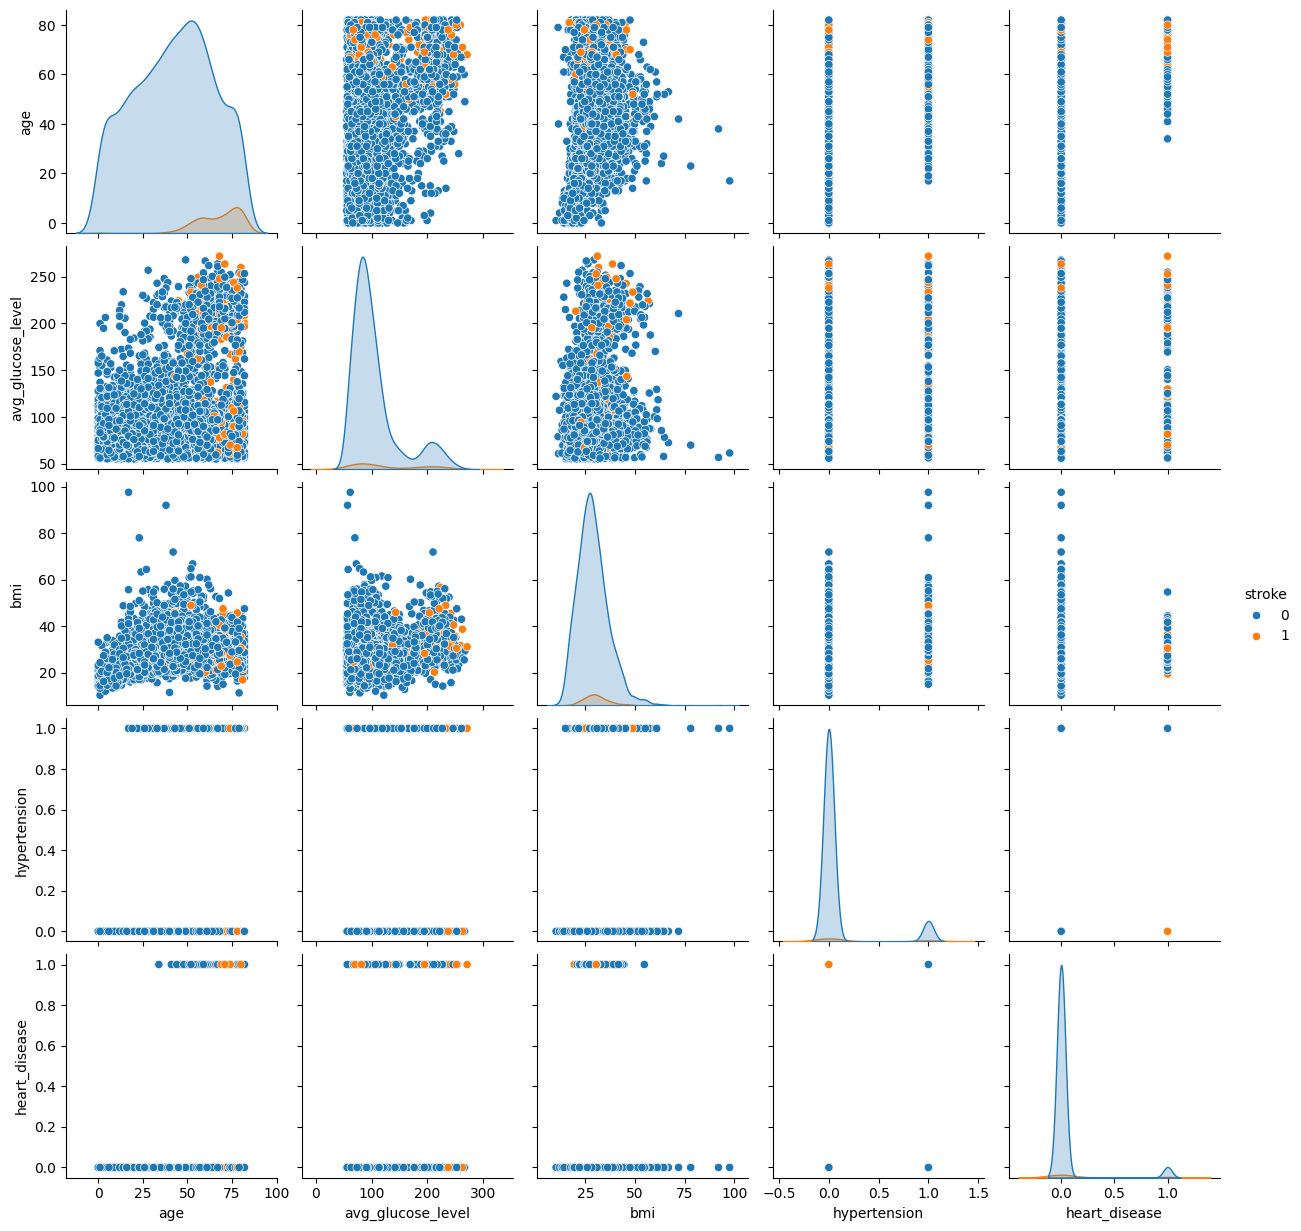

In [29]:
sns.pairplot(train_set[features_num + [target]], hue = target)

In [30]:
features_num = ["age","hypertension","avg_glucose_level"]

In [31]:
features_cat = ["gender","work_type","Residence_type","smoking_status"]

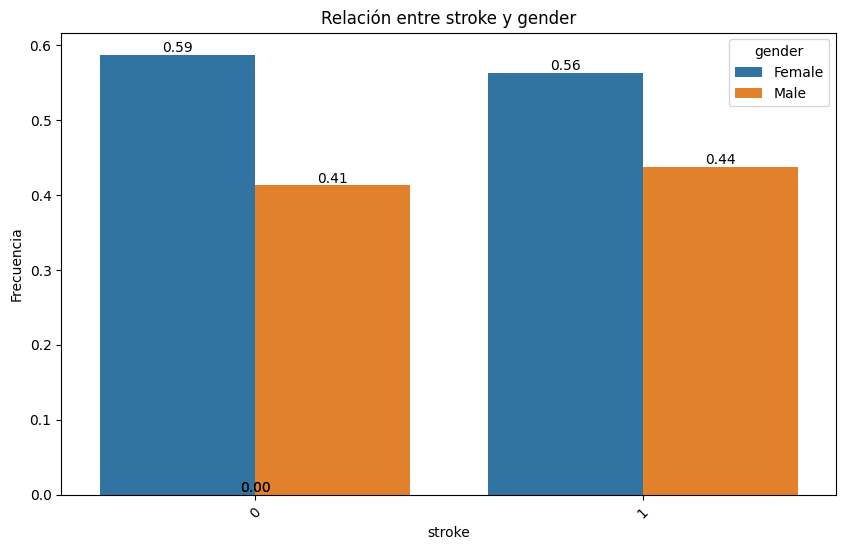

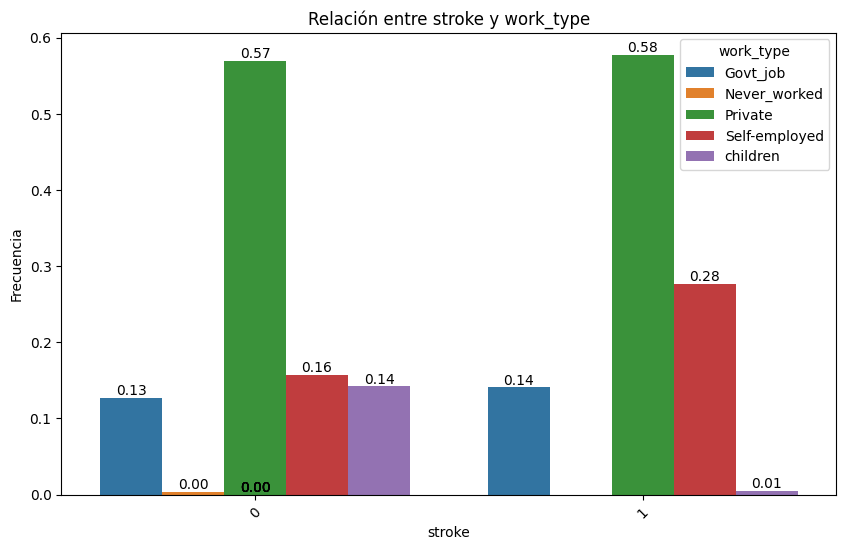

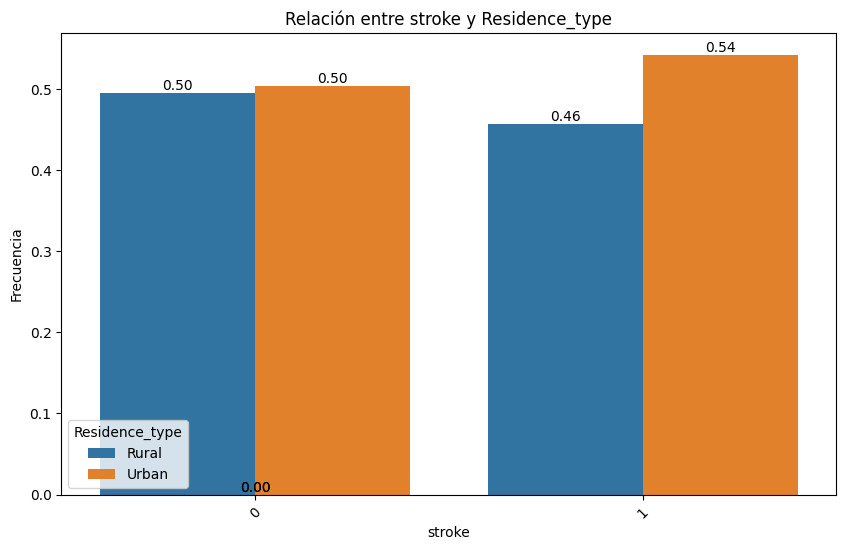

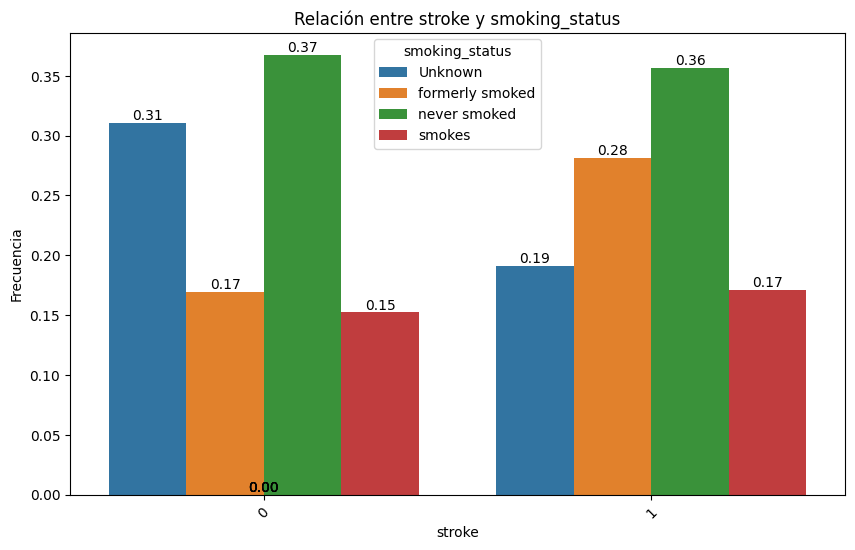

In [32]:
for feat in features_cat:
    bt.plot_categorical_relationship_fin(train_set, target, feat, show_values= True, relative_freq= True)

In [33]:
categories = [["Female","Male"], ["Self-employed","Private","Govt_job","children","Never_worked"], ["Rural","Urban"], ["formerly smoked","never smoked","smokes","Unknown"]]
encoder = OrdinalEncoder(categories= categories)

train_set[["gender","work_type","Residence_type","smoking_status"]] = encoder.fit_transform(train_set[["gender","work_type","Residence_type","smoking_status"]])
test_set[["gender","work_type","Residence_type","smoking_status"]] = encoder.transform(test_set[["gender","work_type","Residence_type","smoking_status"]])

In [34]:
train_set[["gender","work_type","Residence_type","smoking_status"]]

,gender,work_type,Residence_type,smoking_status
845,0.0,1.0,1.0,1.0
3744,1.0,1.0,0.0,1.0
4183,0.0,0.0,0.0,1.0
3409,1.0,1.0,1.0,2.0
284,1.0,2.0,1.0,3.0
...,...,...,...,...
1434,0.0,1.0,1.0,0.0
461,0.0,3.0,0.0,3.0
1052,0.0,1.0,0.0,0.0
1757,1.0,1.0,1.0,3.0


array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'hypertension'}>],
       [<Axes: title={'center': 'avg_glucose_level'}>, <Axes: >]],
      dtype=object)

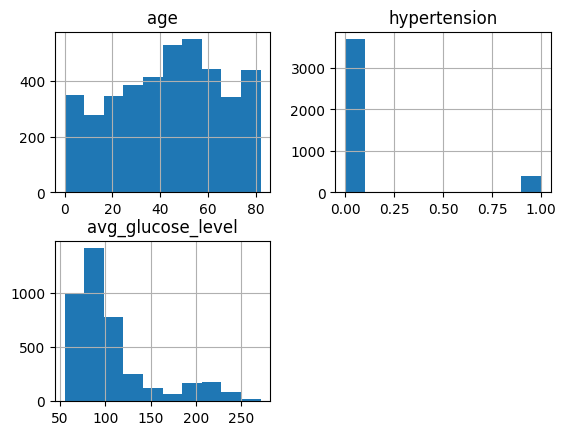

In [35]:
train_set[features_num].hist()

<Axes: >

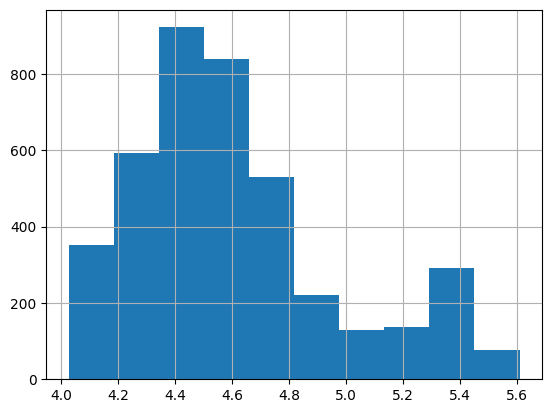

In [36]:
(train_set["avg_glucose_level"]+1).apply(np.log).hist()

<Axes: >

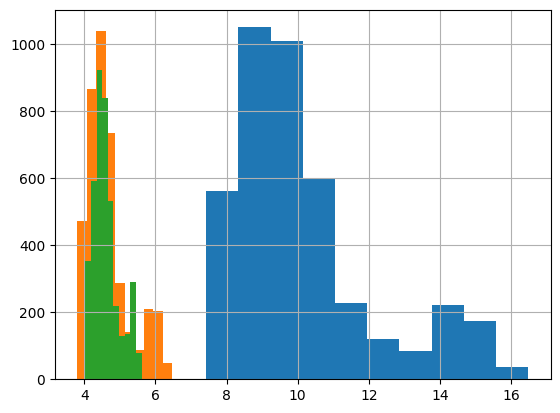

In [37]:
np.sqrt(train_set["avg_glucose_level"]).hist() 
np.cbrt(train_set["avg_glucose_level"]).hist() 
np.log1p(train_set["avg_glucose_level"]).hist() 

<Axes: >

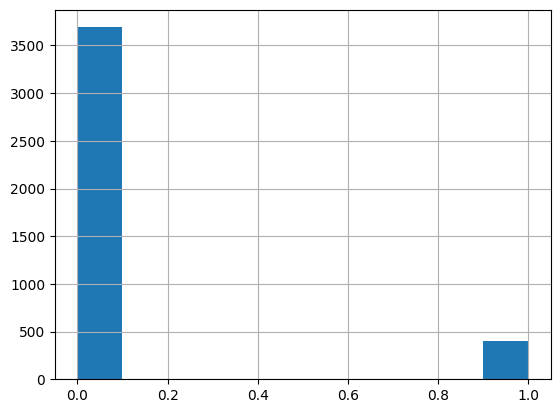

In [38]:
train_set["hypertension"].apply(np.sqrt).hist()

<Axes: >

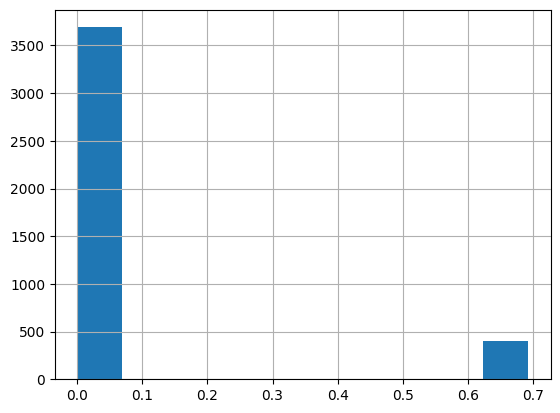

In [39]:
np.log(train_set["hypertension"]+1).hist()

In [40]:
train_set["avg_glucose_level"] = np.sqrt(train_set["avg_glucose_level"])
test_set["avg_glucose_level"] = np.sqrt(test_set["avg_glucose_level"])

In [41]:
train_set

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
845,0.0,48,0,0,Yes,1.0,1.0,8.319255,33.1,1.0,0
3744,1.0,15,0,0,No,1.0,0.0,11.056672,21.0,1.0,0
4183,0.0,67,0,0,Yes,0.0,0.0,10.508092,24.9,1.0,0
3409,1.0,44,0,0,Yes,1.0,1.0,8.087645,24.8,2.0,0
284,1.0,14,0,0,No,2.0,1.0,9.074139,31.6,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...
1434,0.0,45,0,0,Yes,1.0,1.0,9.636389,35.1,0.0,0
461,0.0,16,0,0,No,3.0,0.0,10.652230,19.5,3.0,0
1052,0.0,61,0,0,Yes,1.0,0.0,8.868484,36.2,0.0,0
1757,1.0,31,0,0,Yes,1.0,1.0,8.605231,26.0,3.0,0


In [42]:
scaler = StandardScaler()

In [43]:
train_set[features_num] = scaler.fit_transform(train_set[features_num])

In [44]:
test_set[features_num] = scaler.transform(test_set[features_num])

In [45]:
train_set[features_num].describe()

,age,hypertension,avg_glucose_level
count,4.088000e+03,4.088000e+03,4.088000e+03
mean,1.216683e-16,-1.564306e-17,1.964074e-16
std,1.000122e+00,1.000122e+00,1.000122e+00
min,-1.916392e+00,-3.279618e-01,-1.356397e+00
25%,-7.667732e-01,-3.279618e-01,-6.673090e-01
50%,7.333299e-02,-3.279618e-01,-2.664641e-01
75%,7.807908e-01,-3.279618e-01,2.861923e-01
max,1.709329e+00,3.049136e+00,3.205865e+00


In [46]:
test_set[features_num].describe()

,age,hypertension,avg_glucose_level
count,1022.000000,1022.000000,1022.000000
mean,-0.027905,0.005783,-0.021195
std,1.003594,1.008314,1.000812
min,-1.916392,-0.327962,-1.351652
25%,-0.855205,-0.327962,-0.674832
50%,-0.015099,-0.327962,-0.275400
75%,0.780791,-0.327962,0.274810
max,1.709329,3.049136,3.142545


In [47]:
train_set

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
845,0.0,0.205981,-0.327962,0,Yes,1.0,1.0,-0.905737,33.1,1.0,0
3744,1.0,-1.253150,-0.327962,0,No,1.0,0.0,0.472680,21.0,1.0,0
4183,0.0,1.046088,-0.327962,0,Yes,0.0,0.0,0.196445,24.9,1.0,0
3409,1.0,0.029117,-0.327962,0,Yes,1.0,1.0,-1.022364,24.8,2.0,0
284,1.0,-1.297367,-0.327962,0,No,2.0,1.0,-0.525618,31.6,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...
1434,0.0,0.073333,-0.327962,0,Yes,1.0,1.0,-0.242498,35.1,0.0,0
461,0.0,-1.208934,-0.327962,0,No,3.0,0.0,0.269025,19.5,3.0,0
1052,0.0,0.780791,-0.327962,0,Yes,1.0,0.0,-0.629175,36.2,0.0,0
1757,1.0,-0.545693,-0.327962,0,Yes,1.0,1.0,-0.761735,26.0,3.0,0


In [48]:
features_set_cat_1 = ["age","smoking_status"] 
features_set_cat_2 = features_cat

In [49]:
features_set_cat_1

['age', 'smoking_status']

In [50]:
features_set_cat_2

['gender', 'work_type', 'Residence_type', 'smoking_status']

In [51]:
X_train = train_set[features_set_cat_1]
y_train = train_set[target]

X_test = test_set[features_set_cat_1]
y_test = test_set[target]

In [52]:
log_class_1 = LogisticRegression(max_iter = 1000,class_weight="balanced") 

log_class_1.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [53]:
def metrics_titanic(model, X, y_target):
    y_pred = model.predict(X)
    ConfusionMatrixDisplay.from_predictions(y_target, y_pred)
    print(classification_report(y_target, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.72      0.83      3889
           1       0.13      0.78      0.22       199

    accuracy                           0.73      4088
   macro avg       0.56      0.75      0.53      4088
weighted avg       0.94      0.73      0.80      4088



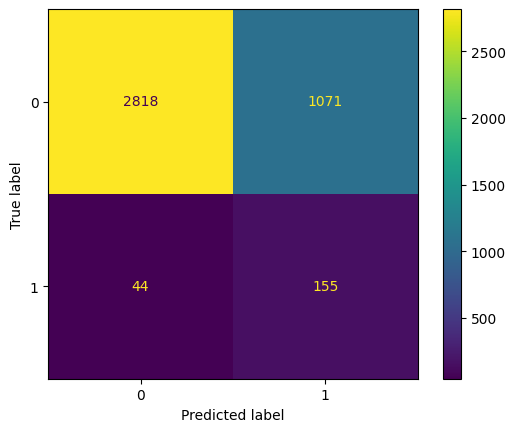

In [ ]:
metrics_titanic(log_class_1, X_train, y_train)

              precision    recall  f1-score   support

           0       0.99      0.74      0.84       972
           1       0.14      0.82      0.24        50

    accuracy                           0.74      1022
   macro avg       0.56      0.78      0.54      1022
weighted avg       0.95      0.74      0.81      1022



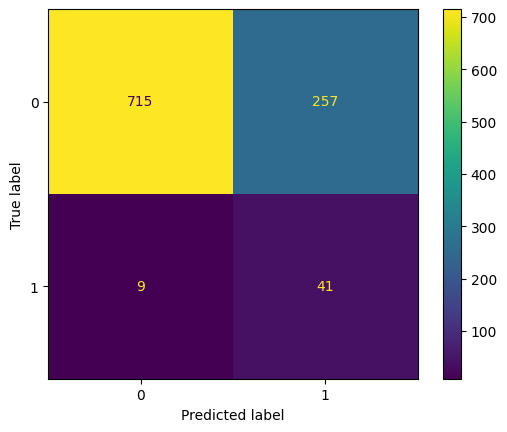

In [55]:
metrics_titanic(log_class_1, X_test, y_test)

AUROC: 0.83


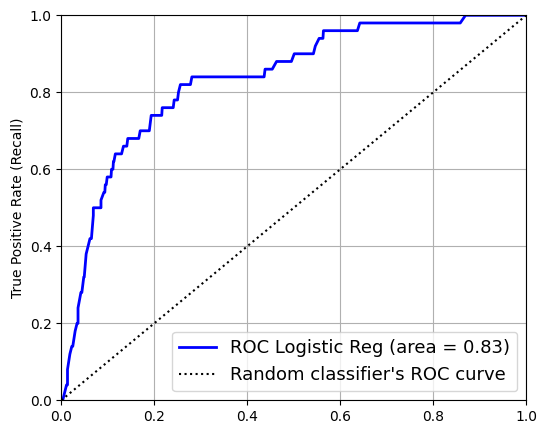

In [56]:
from sklearn.metrics import roc_curve, auc
scores = log_class_1.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, scores[:,1])
roc_auc = auc(fpr,tpr)
print("AUROC: %.2f" %(roc_auc))
plt.figure(figsize=(6, 5))  
plt.plot(fpr, tpr, linewidth=2, color= "blue", label=f"ROC Logistic Reg (area = {roc_auc:0.2f})")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")
plt.ylabel('True Positive Rate (Recall)')
plt.grid()
plt.axis([0, 1, 0, 1])
plt.legend(loc="lower right", fontsize=13)
plt.show()